In [1]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9" 

dataset = QM9(DATA_ROOT)

/opt/anaconda3/envs/equi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/equi/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


In [2]:
import torch
from torch import nn

class DummyModel(nn.Module):
    def __init__(self, num_nodes: int, num_atom_types: int = 0):
        super().__init__()
        num_positions = 3
        # Add atom type as target if necessary
        num_targets = num_positions + num_atom_types
        self.hidden_layer = nn.Linear(num_nodes * num_targets, 100)
        self.hidden_layer_2 = nn.Linear(100, 100)
        self.layer = nn.Linear(
            100, num_nodes * num_targets
        )

    def forward(self, noise: torch.Tensor):
        return self.layer(self.hidden_layer_2(self.hidden_layer(noise)))

In [3]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

SPHERICAL UTILS

In [4]:
import torch


def sphere_normalize(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Normalize each position independently onto S^3.
    """
    return x / x.norm(dim=-1, keepdim=True).clamp_min(eps)


def probs_to_sphere(p: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Map simplex probabilities to positive orthant of the sphere:
        phi(p) = sqrt(p)
    p: [N_atoms, 5], sum=1 along last dim
    Returns x in S^3_+ at each position: [N_atoms, 5]
    """
    p = p.clamp_min(eps)
    p = p / p.sum(dim=-1, keepdim=True).clamp_min(eps)
    x = torch.sqrt(p)
    return sphere_normalize(x, eps)


def sphere_to_probs(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Inverse map of phi on S^3_+:
        p_i = x_i^2
    x: [N_atoms, 5]
    returns probs: [N_atoms, 5]
    """
    x = sphere_normalize(x, eps).clamp_min(0.0)
    p = x.pow(2)
    return p / p.sum(dim=-1, keepdim=True).clamp_min(eps)


def sphere_project_tangent(x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """
    Project v onto tangent space at x, positionwise.
    x, v: [N_atoms, 5]
    """
    return v - (x * v).sum(dim=-1, keepdim=True) * x


def product_tangent_norm(v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Product metric norm:
        ||v||_g^2 = sum_l ||v_l||_2^2
    v: [N_atoms, 5]
    returns: [N_atoms, 1]
    """
    return torch.clamp(torch.norm(v, dim=-1, keepdim=True), min=1e-8)


def sphere_log(x: torch.Tensor, y: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere log map on S^3.

    x, y: [N_atoms, 5], each position normalized.
    returns: [N_atoms, 5], tangent at x
    """
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1, keepdim=True).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
    theta = torch.acos(dot)  # [..., L, 1]

    u = y - dot * x
    u_norm = u.norm(dim=-1, keepdim=True)

    scale = theta / u_norm.clamp_min(eps)
    out = scale * u

    small = theta < 1e-5
    first_order = sphere_project_tangent(x, y - x)
    out = torch.where(small, first_order, out)
    return sphere_project_tangent(x, out)


def sphere_exp(x: torch.Tensor, v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Positionwise sphere exp map on S^3.

    x: [N_atoms, 5] normalized
    v: [N_atoms, 5] tangent at x
    returns: [N_atoms, 5] on sphere
    """
    x = sphere_normalize(x, eps)
    v = sphere_project_tangent(x, v)

    v_norm = v.norm(dim=-1, keepdim=True)
    direction = v / v_norm.clamp_min(eps)

    out = torch.cos(v_norm) * x + torch.sin(v_norm) * direction
    approx = sphere_normalize(x + v, eps)

    out = torch.where(v_norm < 1e-5, approx, out)
    return sphere_normalize(out, eps)


def geodesic_distance(
    x: torch.Tensor,  # [N_x, N_atoms, 5]
    y: torch.Tensor,  # [N_y, N_atoms, 5]
    eps: float = 1e-8,
) -> torch.Tensor:
    x = sphere_normalize(x, eps)
    y = sphere_normalize(y, eps)

    dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7) 
    return torch.acos(dot)  # [N_mol, max_atoms]

EGNN

In [5]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        gen_types = self.type_embedding_out(gen_feats)

        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types

VISUALIZATION FUNCTIONS

In [6]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_mol: torch.Tensor, real_mol: torch.Tensor):
    gen_mol = gen_mol.view(-1, 3).detach().cpu().numpy()
    real_mol = real_mol.view(-1, 3).detach().cpu().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(gen_mol[:, 0], gen_mol[:, 1], gen_mol[:, 2], color='red', label='Generated Molecule')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(real_mol[:, 0], real_mol[:, 1], real_mol[:, 2], color='blue', label='Real Molecule')
    ax2.set_title('Real Molecule')
    ax2.legend()
    plt.show()

def visualize_both_molecules_with_atom_types(
    gen_pos: torch.Tensor,
    gen_types: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    mol_idx: int = 0,
):
    # Select one molecule from batched positions: [Num_mol, Num_atoms, 3]
    if gen_pos.dim() == 3:
        gen_pos = gen_pos[mol_idx]
    if real_pos.dim() == 3:
        real_pos = real_pos[mol_idx]

    # Select one molecule from batched type vectors: [Num_mol, Num_atoms, Num_types]
    if gen_types.dim() == 3:
        gen_types = gen_types[mol_idx]
    if real_types.dim() == 3:
        real_types = real_types[mol_idx]

    # Select one molecule from batched type labels: [Num_mol, Num_atoms]
    if gen_types.dim() == 2 and gen_types.shape[0] != gen_pos.shape[0]:
        gen_types = gen_types[mol_idx]
    if real_types.dim() == 2 and real_types.shape[0] != real_pos.shape[0]:
        real_types = real_types[mol_idx]

    # Convert one-hot/prob/type vectors [Num_atoms, Num_types] to labels [Num_atoms]
    if gen_types.dim() == 2:
        gen_types = gen_types.argmax(dim=-1)
    if real_types.dim() == 2:
        real_types = real_types.argmax(dim=-1)

    gen_pos_np = gen_pos.detach().cpu().numpy()
    real_pos_np = real_pos.detach().cpu().numpy()

    gen_types_cpu = gen_types.detach().cpu().long()
    real_types_cpu = real_types.detach().cpu().long()

    fig = plt.figure(figsize=(12, 6))

    ax1 = fig.add_subplot(121, projection="3d")
    for atom_type in torch.unique(gen_types_cpu):
        mask = (gen_types_cpu == atom_type).numpy()
        ax1.scatter(
            gen_pos_np[mask, 0],
            gen_pos_np[mask, 1],
            gen_pos_np[mask, 2],
            label=f"Atom Type {int(atom_type.item())}",
        )
    ax1.set_title("Generated Molecule")
    ax1.legend()

    ax2 = fig.add_subplot(122, projection="3d")
    for atom_type in torch.unique(real_types_cpu):
        mask = (real_types_cpu == atom_type).numpy()
        ax2.scatter(
            real_pos_np[mask, 0],
            real_pos_np[mask, 1],
            real_pos_np[mask, 2],
            label=f"Atom Type {int(atom_type.item())}",
        )
    ax2.set_title("Real Molecule")
    ax2.legend()

    plt.show()

def plot_loss(loss_list):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(loss_list)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("Training Loss")
    ax.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# Adding Kabsch algorithm and Hungarian method
from torch_linear_assignment import batch_linear_assignment

@torch.no_grad()
def _kabsch_rotations(gen_pos, real_pos):
    """
    Supports:
        gen_pos:  [N_gen, N_atoms, 3]
        gen_pos:  [N_gen, N_real, N_atoms, 3]
        real_pos: [N_real, N_atoms, 3]

    Returns:
        R: [N_gen, N_real, 3, 3]

    R[g, r] aligns gen_pos[g] or gen_pos[g, r] to real_pos[r].
    """
    if real_pos.ndim != 3:
        raise ValueError(f"real_pos must be [N_real, N_atoms, 3], got {real_pos.shape}")

    if gen_pos.ndim == 3:
        if gen_pos.shape[1:] != real_pos.shape[1:]:
            raise ValueError(
                f"Shape mismatch: gen_pos {gen_pos.shape}, real_pos {real_pos.shape}"
            )

        gen_c = gen_pos - gen_pos.mean(dim=1, keepdim=True)
        real_c = real_pos - real_pos.mean(dim=1, keepdim=True)

        # H[g, r] = gen_c[g].T @ real_c[r]
        H = torch.einsum("gni,rnj->grij", gen_c, real_c)

    elif gen_pos.ndim == 4:
        if gen_pos.shape[1] != real_pos.shape[0]:
            raise ValueError(
                f"Pairwise gen_pos has N_real={gen_pos.shape[1]}, "
                f"but real_pos has N_real={real_pos.shape[0]}"
            )
        if gen_pos.shape[2:] != real_pos.shape[1:]:
            raise ValueError(
                f"Shape mismatch: gen_pos {gen_pos.shape}, real_pos {real_pos.shape}"
            )

        gen_c = gen_pos - gen_pos.mean(dim=2, keepdim=True)
        real_c = real_pos - real_pos.mean(dim=1, keepdim=True)

        # H[g, r] = gen_c[g, r].T @ real_c[r]
        H = torch.einsum("grni,rnj->grij", gen_c, real_c)

    else:
        raise ValueError(f"gen_pos must be 3D or 4D, got {gen_pos.shape}")

    H_flat = H.reshape(-1, 3, 3)

    U, S, Vh = torch.linalg.svd(H_flat)

    V = Vh.transpose(-2, -1)
    Ut = U.transpose(-2, -1)

    R = V @ Ut

    det = torch.det(R)
    mask = det < 0

    if mask.any():
        V = V.clone()
        V[mask, :, -1] *= -1
        R = V @ Ut

    return R.reshape(H.shape[0], H.shape[1], 3, 3)


def _hungarian_method_batched(
    gen_types,
    real_types,
    sigma,
    eps,
):
    cost_matrix = _build_cost_matrix(
        gen=gen_types,
        real=real_types,
        sigma=sigma,
        eps=eps,
    )

    N_gen = cost_matrix.shape[0]
    N_real = cost_matrix.shape[1]
    N_atoms = cost_matrix.shape[2]

    cost_flat = cost_matrix.reshape(N_gen * N_real, N_atoms, N_atoms).contiguous()

    with torch.no_grad():
        assignment_flat = batch_linear_assignment(cost_flat)

    assignment = assignment_flat.reshape(N_gen, N_real, N_atoms)

    return assignment


def _build_cost_matrix(gen, real, sigma, eps):
    """
    Supports:
        gen:  [N_gen, N_atoms, D]
        gen:  [N_gen, N_real, N_atoms, D]
        real: [N_real, N_atoms, D]

    returns:
        cost_matrix: [N_gen, N_real, N_atoms_real, N_atoms_gen]

    cost_matrix[g, r, j_real, i_gen] =
        cost of assigning generated atom i to real atom j
    """
    assert real.ndim == 3

    gen = sphere_normalize(gen, eps)
    real = sphere_normalize(real, eps)

    if gen.ndim == 3:
        # gen: [N_gen, N_atoms, D]
        gen_expanded = gen[:, None, None, :, :]      # [N_gen, 1, 1, N_atoms, D]
        real_expanded = real[None, :, :, None, :]    # [1, N_real, N_atoms, 1, D]

    elif gen.ndim == 4:
        # gen: [N_gen, N_real, N_atoms, D]
        gen_expanded = gen[:, :, None, :, :]         # [N_gen, N_real, 1, N_atoms, D]
        real_expanded = real[None, :, :, None, :]    # [1, N_real, N_atoms, 1, D]

    else:
        raise ValueError(f"Expected gen to be 3D or 4D, got shape {gen.shape}")

    dot = (gen_expanded * real_expanded).sum(dim=-1)
    dot = dot.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

    dist = torch.acos(dot)

    cost_matrix = dist.pow(2) / (2 * sigma**2)

    return cost_matrix


def _to_pairwise(gen, n_real):
    if gen.ndim == 3:
        return gen[:, None, :, :].expand(-1, n_real, -1, -1)
    if gen.ndim == 4:
        return gen
    raise ValueError(f"Expected 3D or 4D tensor, got {gen.shape}")


def _pairwise_position_rmse(gen_pos_pairwise, real_pos):
    """
    gen_pos_pairwise: [N_gen, N_real, N_atoms, 3]
    real_pos:         [N_real, N_atoms, 3]

    returns:
        rmse: [N_gen, N_real]
    """
    diff = gen_pos_pairwise - real_pos[None, :, :, :]
    return diff.pow(2).sum(dim=-1).mean(dim=-1).sqrt()


def permute_generated_to_real_order(gen, assignment):
    """
    Supports:
        gen: [N_gen, N_atoms, D]
        gen: [N_gen, N_real, N_atoms, D]

    assignment: [N_gen, N_real, N_atoms]
        assignment[g, r, j_real] = i_gen

    returns:
        gen_perm: [N_gen, N_real, N_atoms, D]
    """
    D = gen.shape[-1]

    if gen.ndim == 3:
        gen_pairwise = gen[:, None, :, :].expand(-1, assignment.shape[1], -1, -1)

    elif gen.ndim == 4:
        gen_pairwise = gen

    else:
        raise ValueError(f"Expected gen to be 3D or 4D, got shape {gen.shape}")

    idx = assignment[..., None].expand(-1, -1, -1, D)

    gen_perm = gen_pairwise.gather(dim=2, index=idx)

    return gen_perm


def apply_pairwise_rotation(gen_pos, R):
    """
    Supports:
        gen_pos: [N_gen, N_atoms, 3]
        gen_pos: [N_gen, N_real, N_atoms, 3]

    R: [N_gen, N_real, 3, 3]

    Returns:
        rotated: [N_gen, N_real, N_atoms, 3]
    """
    if gen_pos.ndim == 3:
        gen_pairwise = gen_pos[:, None, :, :].expand(-1, R.shape[1], -1, -1)
    elif gen_pos.ndim == 4:
        gen_pairwise = gen_pos
    else:
        raise ValueError(f"gen_pos must be 3D or 4D, got {gen_pos.shape}")

    return gen_pairwise @ R


def unpermute_real_order_to_gen_order(x_perm, assignment):
    """
    x_perm: [N_gen, N_real, N_atoms, D]
        tensor currently ordered by real atom index

    assignment: [N_gen, N_real, N_atoms]
        assignment[g, r, j_real] = i_gen

    returns:
        x: [N_gen, N_real, N_atoms, D]
        tensor ordered by original generated atom index
    """
    x = torch.empty_like(x_perm)

    idx = assignment[..., None].expand_as(x_perm)

    x.scatter_(dim=2, index=idx, src=x_perm)

    return x


def find_rotation_and_permutation(
    gen_pos,
    real_pos,
    gen_types,
    real_types,
    sigma,
    eps,
    max_iter,
    pos_tol=1e-1,
    min_iter=1,
):
    g_types = gen_types.clone().detach()
    g_pos = gen_pos.clone().detach()

    N_gen = gen_pos.shape[0]
    N_real = real_pos.shape[0]
    N_atoms = gen_pos.shape[1]

    active = torch.ones(N_gen, N_real, device=gen_pos.device, dtype=torch.bool)

    total_assignment = torch.arange(
        N_atoms,
        device=gen_pos.device,
    ).view(1, 1, N_atoms).expand(N_gen, N_real, N_atoms).clone()

    total_R = torch.eye(
        3,
        device=gen_pos.device,
        dtype=gen_pos.dtype,
    ).view(1, 1, 3, 3).expand(N_gen, N_real, 3, 3).clone()

    for step in range(max_iter):
        old_g_pos = _to_pairwise(g_pos, N_real)
        old_g_types = _to_pairwise(g_types, N_real)

        step_assignment = _hungarian_method_batched(
            g_types,
            real_types,
            sigma=sigma,
            eps=eps,
        )

        cand_g_pos = permute_generated_to_real_order(g_pos, step_assignment)
        cand_g_types = permute_generated_to_real_order(g_types, step_assignment)

        step_R = _kabsch_rotations(cand_g_pos, real_pos)
        cand_g_pos = apply_pairwise_rotation(cand_g_pos, step_R)

        cand_total_assignment = total_assignment.gather(
            dim=2,
            index=step_assignment,
        )

        cand_total_R = total_R @ step_R

        pair_mask = active[..., None, None]
        assign_mask = active[..., None]

        g_pos = torch.where(pair_mask, cand_g_pos, old_g_pos)
        g_types = torch.where(pair_mask, cand_g_types, old_g_types)

        total_assignment = torch.where(
            assign_mask,
            cand_total_assignment,
            total_assignment,
        )

        total_R = torch.where(
            pair_mask,
            cand_total_R,
            total_R,
        )

        rmse = _pairwise_position_rmse(g_pos, real_pos)
        done = rmse <= pos_tol

        if step + 1 < min_iter:
            active = torch.ones_like(done)
        else:
            active = ~done

        if not active.any():
            break

    return total_assignment, total_R, g_pos, g_types

# Testing out the aligning functions

In [102]:
mol = dataset[0]
mol_pos = mol.pos
mol_types = mol.real_atom_types
N_atoms = mol.num_nodes

mol_pos = mol_pos - mol_pos.mean(dim=0, keepdim=True)

# Random permutation
torch.manual_seed(0)
perm = torch.randperm(N_atoms, device=mol_pos.device)

# Random proper rotation matrix, det(R) = +1
A = torch.randn(3, 3, device=mol_pos.device, dtype=mol_pos.dtype)
Q, _ = torch.linalg.qr(A)

if torch.det(Q) < 0:
    Q[:, -1] *= -1

R_true = Q

# Create transformed/generated molecule
gen_pos_test = mol_pos[perm] @ R_true
gen_types_test = mol_types[perm]

# Add batch dimensions
gen_pos_test = gen_pos_test.unsqueeze(0)      # [1, N_atoms, 3]
gen_types_test = gen_types_test.unsqueeze(0)  # [1, N_atoms, 5]

real_pos_test = mol_pos.unsqueeze(0)          # [1, N_atoms, 3]
real_types_test = mol_types.unsqueeze(0) 

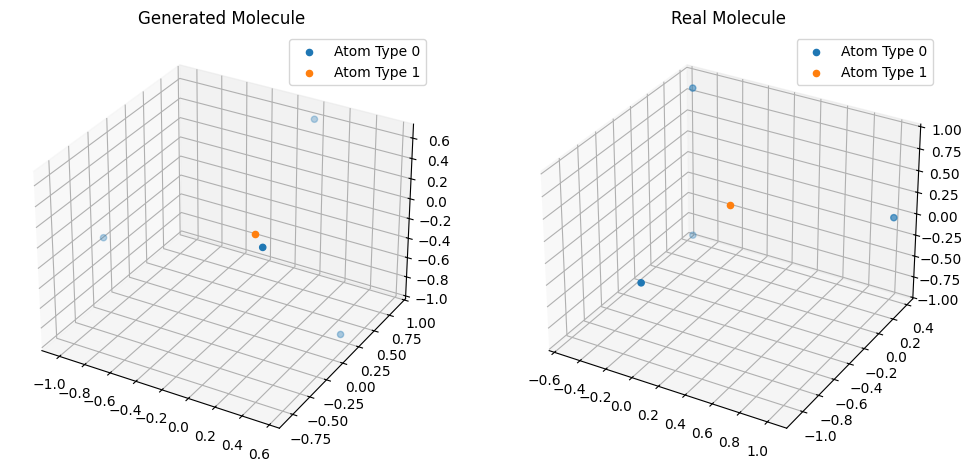

In [103]:
visualize_both_molecules_with_atom_types(
    gen_pos_test,
    gen_types_test,
    real_pos_test,
    real_types_test,
    mol_idx=0,
)

In [104]:
assignment, R, aligned_gen_pos, aligned_gen_types = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=100)

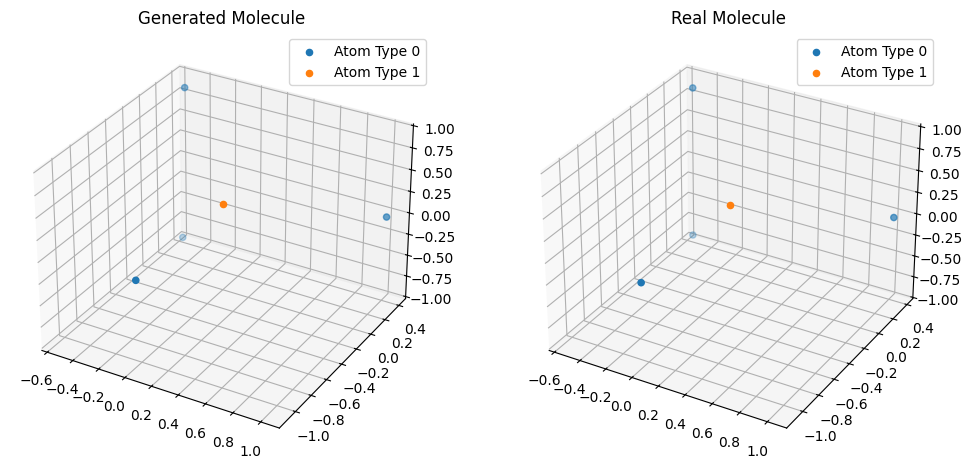

In [105]:
aligned_gen_pos = aligned_gen_pos.squeeze(0)
aligned_gen_types = aligned_gen_types.squeeze(0)

visualize_both_molecules_with_atom_types(
    aligned_gen_pos,
    aligned_gen_types,
    real_pos_test,
    real_types_test,
    mol_idx=0,
)

# Test full alignment and unaligning

Real here is from the total assingnment and rotation


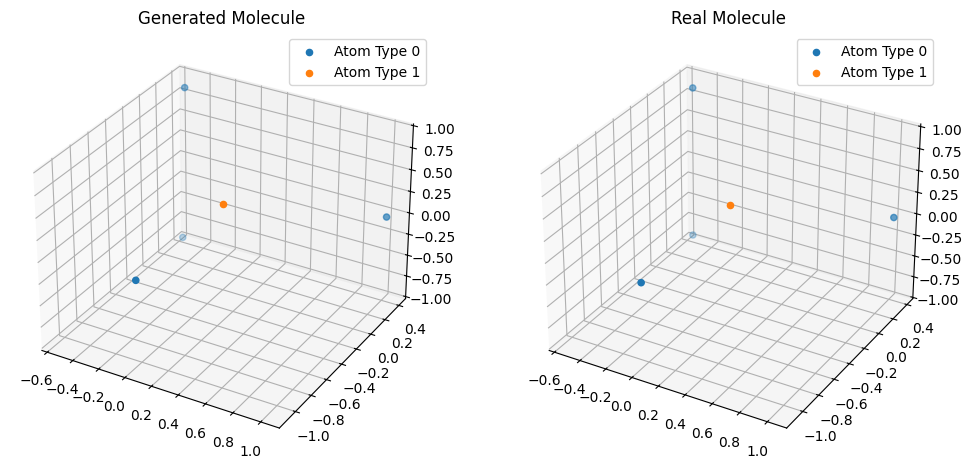

In [106]:
assignment, R, _, _ = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=100)

g_pos_from_total = permute_generated_to_real_order(
    gen_pos_test.detach(),
    assignment,
)

g_types_from_total = permute_generated_to_real_order(gen_types_test, assignment)

g_pos_from_total = apply_pairwise_rotation(
    g_pos_from_total,
    R,
)

g_types_from_total = g_types_from_total.squeeze(0)
g_pos_from_total = g_pos_from_total.squeeze(0)

print("Real here is from the total assingnment and rotation")
visualize_both_molecules_with_atom_types(
    g_pos_from_total,
    g_types_from_total,
    real_pos_test,
    real_types_test,
    mol_idx=0,
)

In [107]:
g_types_from_total = g_types_from_total.unsqueeze(0)
g_pos_from_total = g_pos_from_total.unsqueeze(0)

Real here is the original rotated version


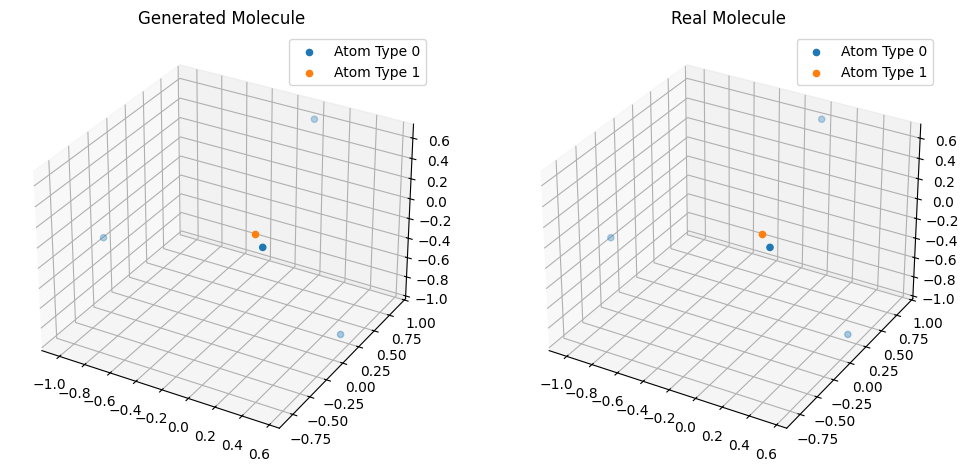

In [108]:
inv_R = R.transpose(-2, -1)
g_pos_from_total = g_pos_from_total @ inv_R
g_pos_from_total = unpermute_real_order_to_gen_order(g_pos_from_total, assignment)
g_types_from_total = unpermute_real_order_to_gen_order(g_types_from_total, assignment=assignment)

g_pos_from_total = g_pos_from_total.squeeze(0)
g_types_from_total = g_types_from_total.squeeze(0)

print("Real here is the original rotated version")
visualize_both_molecules_with_atom_types(
    g_pos_from_total,
    g_types_from_total,
    gen_pos_test,
    gen_types_test,
    mol_idx=0,
)

Works!


# For multiple:

In [109]:
indices = []
for i in range(2000):
    if dataset[i].num_nodes == 5:
        indices.append(i)
print(len(indices))

5


In [110]:
mol_indices = indices

real_pos_list = []
real_types_list = []
gen_pos_list = []
gen_types_list = []
perms = []
R_trues = []

torch.manual_seed(0)

for idx in mol_indices:
    mol = dataset[idx]

    mol_pos = mol.pos.float()
    mol_types = mol.real_atom_types.float()
    N_atoms = mol.num_nodes

    mol_pos = mol_pos - mol_pos.mean(dim=0, keepdim=True)

    # Random permutation
    perm = torch.randperm(N_atoms, device=mol_pos.device)

    # Random proper rotation matrix, det(R) = +1
    A = torch.randn(3, 3, device=mol_pos.device, dtype=mol_pos.dtype)
    Q, _ = torch.linalg.qr(A)

    if torch.det(Q) < 0:
        Q[:, -1] *= -1

    R_true = Q

    # Create transformed/generated molecule
    gen_pos = mol_pos[perm] @ R_true
    gen_types = mol_types[perm]

    real_pos_list.append(mol_pos)
    real_types_list.append(mol_types)

    gen_pos_list.append(gen_pos)
    gen_types_list.append(gen_types)

    perms.append(perm)
    R_trues.append(R_true)

gen_pos_test = torch.stack(gen_pos_list, dim=0)        # [2, N_atoms, 3]
gen_types_test = torch.stack(gen_types_list, dim=0)    # [2, N_atoms, 5]

real_pos_test = torch.stack(real_pos_list, dim=0)      # [2, N_atoms, 3]
real_types_test = torch.stack(real_types_list, dim=0)  # [2, N_atoms, 5]

perms = torch.stack(perms, dim=0)                      # [2, N_atoms]
R_trues = torch.stack(R_trues, dim=0)                  # [2, 3, 3]

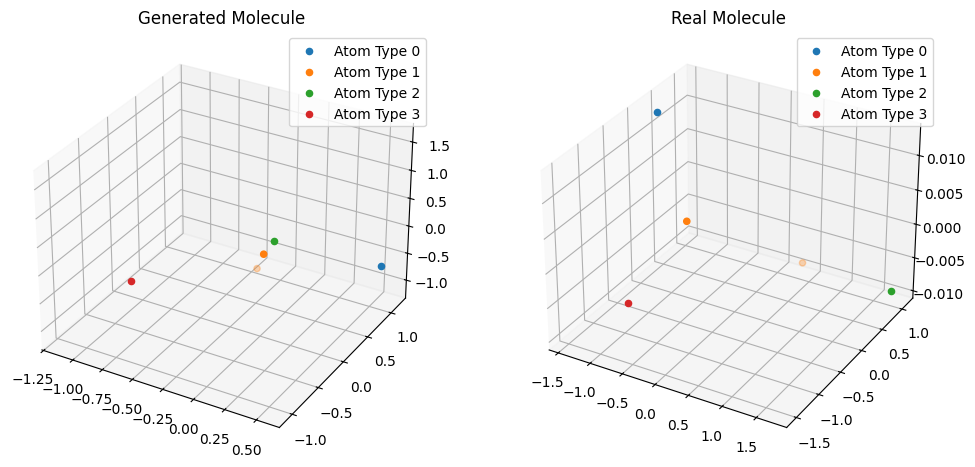

In [111]:
visualize_both_molecules_with_atom_types(
    gen_pos_test,
    gen_types_test,
    real_pos_test,
    real_types_test,
    mol_idx=2,
)

In [118]:
assignment, R, aligned_gen_pos, aligned_gen_types = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=100)

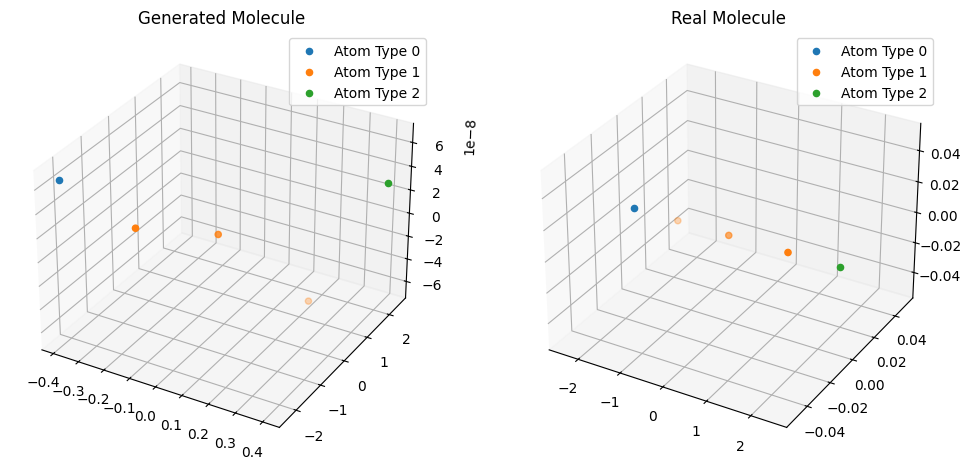

In [119]:
MOL_INDEX = 1

visualize_both_molecules_with_atom_types(
    aligned_gen_pos[:, MOL_INDEX, :, :],
    aligned_gen_types[:, MOL_INDEX, :, :],
    real_pos_test,
    real_types_test,
    mol_idx=MOL_INDEX,
)

# Test again full alignment and unaligning methods on batch

In [145]:
assignment, R, g_pos_direct, g_types_direct = find_rotation_and_permutation(gen_pos_test, real_pos_test, gen_types_test, real_types_test, sigma=1.0, eps=1e-8, max_iter=1000)

g_pos_from_total = permute_generated_to_real_order(
    gen_pos_test.detach(),
    assignment,
)

g_types_from_total = permute_generated_to_real_order(gen_types_test, assignment)

g_pos_from_total = apply_pairwise_rotation(
    g_pos_from_total,
    R,
)

real here is from full rotation and assignment


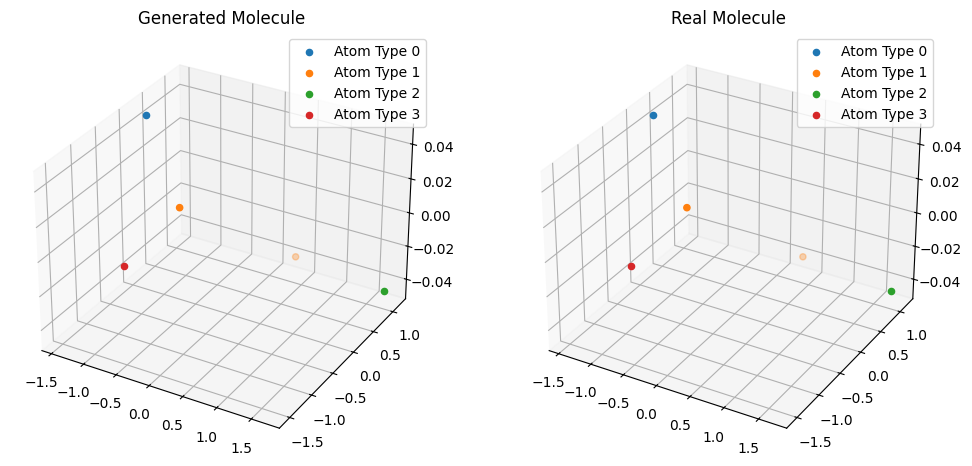

In [ ]:

MOL_INDEX = 3

print("real here is from full rotation and assignment")
visualize_both_molecules_with_atom_types(
    g_pos_from_total[:, MOL_INDEX, :, :],
    g_types_from_total[:, MOL_INDEX, :, :],
    g_pos_direct[:, MOL_INDEX, :, :],
    g_types_direct[:, MOL_INDEX, :, :],
    mol_idx=MOL_INDEX,
)

In [132]:
# Testing unaligning
inv_R = R.transpose(-2, -1)
g_pos_from_total = g_pos_from_total @ inv_R
g_pos_from_total = unpermute_real_order_to_gen_order(g_pos_from_total, assignment)
g_types_from_total = unpermute_real_order_to_gen_order(g_types_from_total, assignment=assignment)

real here is from full rotation and assignment, back aligned


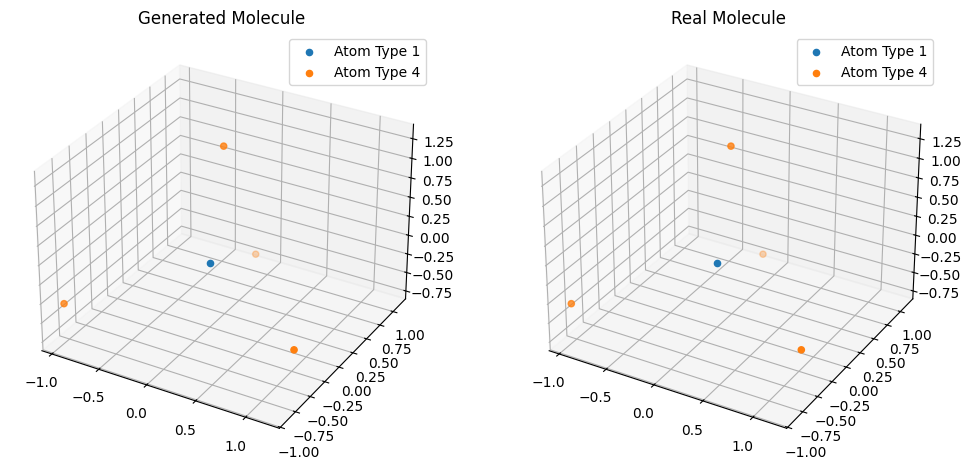

In [139]:
MOL_INDEX = 4

print("real here is from full rotation and assignment, back aligned")
visualize_both_molecules_with_atom_types(
    g_pos_from_total[:, MOL_INDEX, :, :],
    g_types_from_total[:, MOL_INDEX, :, :],
    gen_pos_test,
    gen_types_test,
    mol_idx=MOL_INDEX,
)

---

In [ ]:
def compute_aligning_drift_loss(
    gen_pos: torch.Tensor,
    real_pos: torch.Tensor,
    gen_types_sphere: torch.Tensor,
    real_types: torch.Tensor,
    posit_sigma: float = 1.0,
    types_sigma: float = 1.0,
    eps: float = 1e-8,
    scale_loss: float = 1.0,
) -> tuple[torch.Tensor, dict[str, float]]:
    """
    Drifting field loss directly on 3D molecules by aligning the generated molecules with the real ones.
    Assumes that x_gen_sphere is already mapped to the spherical space

    Returns (loss, stats) where stats is a flat dict of float diagnostics safe to
    pass directly to self.log(). Raises TrainingDivergedException on non-finite loss.
    """
    real_types = real_types.float()

    N_gen = gen_pos.shape[0]
    N_real = real_pos.shape[0]

    permutation, R, aligned_posit_pos, aligned_types_pos = find_rotation_and_permutation(gen_pos, real_pos, gen_types_sphere, real_types, posit_sigma, eps, max_iter=10)
    permutation, R, aligned_posit_neg, aligned_types_neg = find_rotation_and_permutation(gen_pos, gen_pos, gen_types_sphere, gen_types_sphere, posit_sigma, eps, max_iter=10)

    # Distances of shape [N_gen, N_real/N_gen] and Differences of shape [N_gen, N_real/N_gen, N_atoms, 3/5]
    posit_dist_pos, posit_diff_pos = _pairwise_geodesic_distance_and_log(aligned_posit_pos, real_pos, "euclidean", eps)
    posit_dist_neg, posit_diff_neg = _pairwise_geodesic_distance_and_log(aligned_posit_neg, gen_pos, "euclidean", eps)

    types_dist_pos, types_diff_pos = _pairwise_geodesic_distance_and_log(aligned_types_pos, real_types, "spherical", eps)
    types_dist_neg, types_diff_neg = _pairwise_geodesic_distance_and_log(aligned_types_neg, gen_types_sphere, "spherical", eps)

    # PERHAPS DIVIDE DIST BY SQRT N_ATOMS

    # Ignore self if y_neg is x
    eye = torch.eye(N_gen, device=gen_pos.device, dtype=torch.bool)
    posit_dist_neg = posit_dist_neg.masked_fill(eye, 1e6)
    types_dist_neg = types_dist_neg.masked_fill(eye, 1e6)
    
    V_posit = _compute_V_at_sigma(posit_dist_pos, posit_dist_neg, posit_diff_pos, posit_diff_neg, permutation, R, posit_sigma, eps)
    V_types = _compute_V_at_sigma(types_dist_pos, types_dist_neg, types_diff_pos, types_diff_neg, permutation, R, types_sigma, eps, euclidean=False)

    V_types = sphere_project_tangent(gen_types_sphere, V_types)
    # PERHAPS HERE ADD SCALING OF DRIFTING FIELD

    # Calculate targets for each 
    target_posit = (gen_pos + V_posit).detach()
    target_types = sphere_exp(gen_types_sphere, V_types, eps).detach()

    # Calculate distances per molecule on each manifold
    molecule_position_dist = ((gen_pos - target_posit) ** 2).sum(dim=-1).sum(dim=-1)    # shape: [N_gen]
    molecule_types_dist = (geodesic_distance(gen_types_sphere, target_types, eps) ** 2).sum(dim=-1) # shape: [N_gen]

    loss = (molecule_position_dist + scale_loss * molecule_types_dist).mean()
    
    return loss, molecule_position_dist, molecule_types_dist


def _pairwise_geodesic_distance_and_log(
        x: torch.Tensor,
        y: torch.Tensor,
        manifold: str = "euclidean",
        eps: float = 1e-8,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Calculates the pairwise distance between atoms for the molecule attributes depending on 
    the specified geodesic distance. Assumed that molecules are aligned.
    Args:
        x: [N_x, N_y, N_atoms, z]
        y: [N_y, N_atoms, z]
    """

    if manifold == "euclidean":
        diff = x - y[None, :, :, :]                              # shape: (N_x, N_y, N_atoms, z)
        sq_dist_per_atom = (diff ** 2).sum(dim=-1)                              # shape: (N_x, N_y, N_atoms)

        sq_distances = sq_dist_per_atom.sum(dim=-1)   # shape: (N_x, N_y)
    elif manifold == "spherical":
        x = sphere_normalize(x, eps)
        y = sphere_normalize(y.unsqueeze(0), eps)

        dot = (x * y).sum(dim=-1).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        theta = torch.acos(dot)  # [N_x, N_y, N_atoms]

        sq_distances = theta.pow(2).sum(dim=-1).clamp_min(eps)  # [N_x, N_y]

        u = y - dot.unsqueeze(-1) * x  # [N_x, N_y, N_atoms, z]
        u_norm = u.norm(dim=-1, keepdim=True)

        scale = theta.unsqueeze(-1) / u_norm.clamp_min(eps)
        out = scale * u

        small = theta.unsqueeze(-1) < 1e-5
        first_order = sphere_project_tangent(x, y - x)

        out = torch.where(small, first_order, out)
        diff = sphere_project_tangent(x, out)  # shape: (N_x, N_y, N_atoms, z)
    else:
        raise ValueError("Undefined manifold.")
    return sq_distances, diff


def _compute_V_at_sigma(dist_pos, dist_neg, diff_pos, diff_neg, permutation, R, sigma, eps=1e-8, euclidean=True):
    # Calculate kernels
    kernel_pos = torch.exp(-dist_pos / (2 * sigma**2))   # shape [N_gen, N_real]
    kernel_neg = torch.exp(-dist_neg / (2 * sigma**2))   # shape [N_gen, N_real]

    # Calculate gradient of kernels towards generated input
    grad_kernel_pos = (diff_pos * kernel_pos.unsqueeze(-1).unsqueeze(-1)) / (sigma**2)  # shape [N_gen, N_real, N_atoms, 3]
    grad_kernel_neg = (diff_neg * kernel_neg.unsqueeze(-1).unsqueeze(-1)) / (sigma**2)  # shape [N_gen, N_gen, N_atoms, 3]

    if euclidean:
        grad_kernel_pos = - grad_kernel_pos
        grad_kernel_neg = - grad_kernel_neg

    # Now we "unalign" the kernel gradient: TODO


    # Drifting positive direction
    V_pos = grad_kernel_pos.sum(dim=1) / (kernel_pos.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1))   # shape [N_gen, N_atoms, 3]
    V_neg = grad_kernel_neg.sum(dim=1) / (kernel_neg.sum(dim=1).clamp_min(eps).unsqueeze(-1).unsqueeze(-1))   # shape [N_gen, N_atoms, 3]

    V_at_sigma = V_pos - V_neg
    return V_at_sigma
